# Estado conceptual

Estaciones detectadas: 12
Celdas activas en matriz: 54


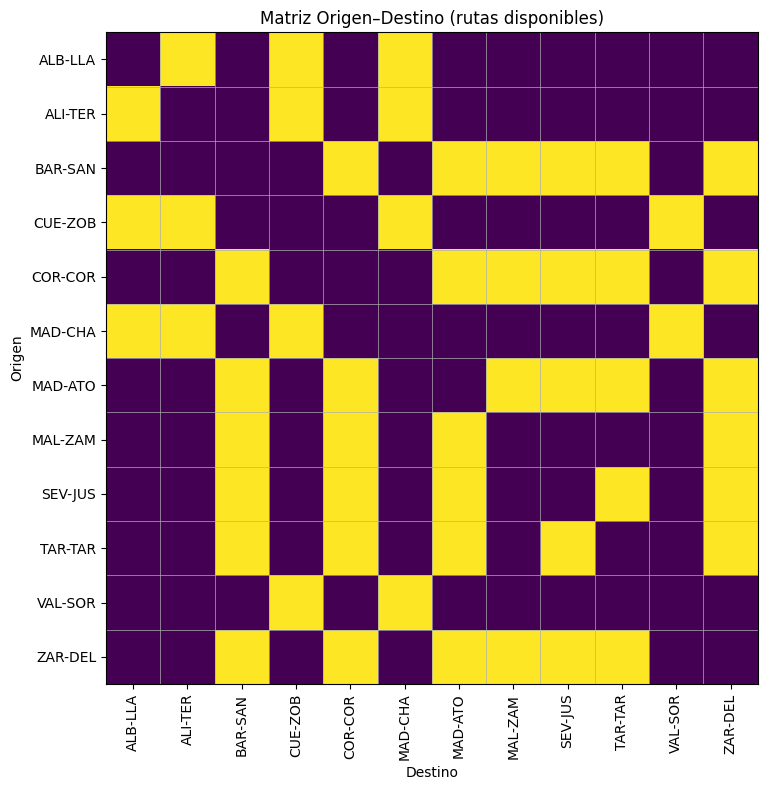

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

# Combinaciones posibles
combinaciones = [['Madrid-Chamartín', 'Valencia-Joaquín Sorolla'],
 ['Barcelona-Sants', 'Zaragoza-Delicias'],
 ['Barcelona-Sants', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Barcelona-Sants'],
 ['Sevilla-Santa Justa', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Sevilla-Santa Justa'],
 ['Madrid-Puerta de Atocha', 'Sevilla-Santa Justa'],
 ['Málaga-María Zambrano', 'Madrid-Puerta de Atocha'],
 ['Barcelona-Sants', 'Madrid-Puerta de Atocha'],
 ['Sevilla-Santa Justa', 'Madrid-Puerta de Atocha'],
 ['Madrid-Puerta de Atocha', 'Málaga-María Zambrano'],
 ['Valencia-Joaquín Sorolla', 'Madrid-Chamartín'],
 ['Madrid-Puerta de Atocha', 'Barcelona-Sants'],
 ['Madrid-Chamartín', 'Albacete-Los Llanos'],
 ['Madrid-Puerta de Atocha', 'Zaragoza-Delicias'],
 ['Málaga-María Zambrano', 'Barcelona-Sants'],
 ['Córdoba', 'Madrid-Puerta de Atocha'],
 ['Madrid-Puerta de Atocha', 'Córdoba'],
 ['Zaragoza-Delicias', 'Madrid-Puerta de Atocha'],
 ['Córdoba', 'Barcelona-Sants'],
 ['Zaragoza-Delicias', 'Barcelona-Sants'],
 ['Madrid-Chamartín', 'Alicante-Terminal'],
 ['Alicante-Terminal', 'Madrid-Chamartín'],
 ['Barcelona-Sants', 'Málaga-María Zambrano'],
 ['Sevilla-Santa Justa', 'Córdoba'],
 ['Córdoba', 'Sevilla-Santa Justa'],
 ['Madrid-Chamartín', 'Cuenca-Fernando Zóbel'],
 ['Zaragoza-Delicias', 'Málaga-María Zambrano'],
 ['Barcelona-Sants', 'Córdoba'],
 ['Zaragoza-Delicias', 'Sevilla-Santa Justa'],
 ['Barcelona-Sants', 'Sevilla-Santa Justa'],
 ['Sevilla-Santa Justa', 'Barcelona-Sants'],
 ['Alicante-Terminal', 'Cuenca-Fernando Zóbel'],
 ['Málaga-María Zambrano', 'Córdoba'],
 ['Málaga-María Zambrano', 'Zaragoza-Delicias'],
 ['Sevilla-Santa Justa', 'Zaragoza-Delicias'],
 ['Cuenca-Fernando Zóbel', 'Madrid-Chamartín'],
 ['Cuenca-Fernando Zóbel', 'Valencia-Joaquín Sorolla'],
 ['Cuenca-Fernando Zóbel', 'Albacete-Los Llanos'],
 ['Albacete-Los Llanos', 'Alicante-Terminal'],
 ['Tarragona-Camp de Tarragona', 'Madrid-Puerta de Atocha'],
 ['Tarragona-Camp de Tarragona', 'Córdoba'],
 ['Córdoba', 'Tarragona-Camp de Tarragona'],
 ['Tarragona-Camp de Tarragona', 'Zaragoza-Delicias'],
 ['Zaragoza-Delicias', 'Tarragona-Camp de Tarragona'],
 ['Córdoba', 'Málaga-María Zambrano'],
 ['Córdoba', 'Zaragoza-Delicias'],
 ['Albacete-Los Llanos', 'Madrid-Chamartín'],
 ['Madrid-Puerta de Atocha', 'Tarragona-Camp de Tarragona'],
 ['Alicante-Terminal', 'Albacete-Los Llanos'],
 ['Albacete-Los Llanos','Cuenca-Fernando Zóbel'],
 ['Valencia-Joaquín Sorolla', 'Cuenca-Fernando Zóbel'],
 ['Zaragoza-Delicias', 'Córdoba'],
 ['Cuenca-Fernando Zóbel', 'Alicante-Terminal']]

# Helpers: quitar acentos + abreviar
def strip_accents(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

def make_abbr(name: str) -> str:
    clean = strip_accents(name)
    parts = [p.strip() for p in clean.split('-') if p.strip()]
    first = parts[0].split()[0][:3].upper() if parts else clean[:3].upper()
    last_block = parts[-1] if parts else clean
    last_word = last_block.split()[-1][:3].upper() if last_block.split() else last_block[:3].upper()
    return f"{first}-{last_word}"

# Estaciones únicas
estaciones = sorted({s for pair in combinaciones for s in pair})
n = len(estaciones)

# Abreviaturas
abbr = {}
used = set()
for s in estaciones:
    a = make_abbr(s)
    if a in used:
        k = 2
        while f"{a}{k}" in used:
            k += 1
        a = f"{a}{k}"
    abbr[s] = a
    used.add(a)

idx = {s: i for i, s in enumerate(estaciones)}

# Rutas v?lidas (incluimos sim?tricas)
rutas = [tuple(p) for p in combinaciones]
rutas_set = set(rutas)
rutas_validas = rutas_set.union({(d, o) for (o, d) in rutas_set})

# Matriz O-D (SIMÉTRICA)
M = np.zeros((n, n), dtype=int)

# Rellenamos rutas v?lidas (con sim?tricas incluidas)
for o, d in rutas_validas:
    io, id_ = idx[o], idx[d]
    M[io, id_] = 1

print(f"Estaciones detectadas: {n}")
print(f"Celdas activas en matriz: {int(M.sum())}")


# Plot
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(M)

labels = [abbr[s] for s in estaciones]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_xlabel("Destino")
ax.set_ylabel("Origen")
ax.set_title("Matriz Origen–Destino (rutas disponibles)")

ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

fig.tight_layout()
# Guardamos archivo
fig.savefig("../figuras/od_matrix.pdf")

# Datos

El primer paso es  unificar los datos y dejarlos con la misma estructura

## Unión del conjunto de datos

### Primer conjunto de datos

In [2]:
import pandas as pd

# Leemos el archivo de billetes
df_1 = pd.read_excel('../data/Billetes.xlsx')

# Seleccionamos las columnas relevantes
df_1 = df_1[['Localizador','Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto']]

# Limpieza de la columna para poder hacer la unión correctamente
df_1['Localizador'] = df_1['Localizador'].astype(str).str.strip().str.upper()

# Vemos si hay valores nan, porque son un problema
df_1['Email'].isna().any()

# Vemos el porcentaje
print( f"Porcentaje de Nan en Email: {df_1['Email'].isna().sum() / len(df_1)}" )

# Como no son muchos, liminamos registros sin email
df_1 = df_1.dropna(subset=['Email'])

# Cantidad total de billetes
print(f"Cantidad total de billetes en el primer conjunto de datos:{len(df_1)}")

df_1[['Fecha', 'Origen', 'Destino', 'Nombre de producto']].head()


Porcentaje de Nan en Email: 0.007151928347035626
Cantidad total de billetes en el primer conjunto de datos:14854


,Fecha,Origen,Destino,Nombre de producto
0,2024-01-31T15:00:00.000+0000,Valencia-Joaquín Sorolla,Madrid-Chamartín,Inicial
1,2024-01-28T11:40:00.000+0000,Barcelona-Sants,Madrid-Puerta de Atocha,Infinita Bistró
2,2024-01-20T10:25:00.000+0000,Madrid-Puerta de Atocha,Barcelona-Sants,Infinita Bistró
3,2024-03-23T15:40:00.000+0000,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial
4,2024-02-21T16:25:00.000+0000,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial


Los valores Nan en el email son un problema, porque no podemos localizar al usuario correspondiente a esos billetes. Además son pocos, por lo que los eliminamos

In [3]:
df_reservas = pd.read_excel('../data/Reservas.xlsx')

# Nos quedamos solo con lo necesario
df_reservas = df_reservas[['Localizador', 'Fecha compra']]

# Limpieza básica del Localizador
df_reservas['Localizador'] = df_reservas['Localizador'].astype(str).str.strip().str.upper()

# Convertimos Fecha compra a datetime (por si viene como texto)
df_reservas['Fecha compra'] = pd.to_datetime(df_reservas['Fecha compra'], errors='coerce')

# Si hay varios registros por Localizador, nos quedamos con la primera compra
df_reservas = (df_reservas
               .dropna(subset=['Localizador'])
               .groupby('Localizador', as_index=False)['Fecha compra']
               .min())


# Unión por Localizador
df_1 = df_1.merge(df_reservas, on='Localizador', how='left')

print(f"Porcentaje sin 'Fecha compra' tras la unión: {df_1['Fecha compra'].isna().mean():.4f}")
# Quitar billetes sin Fecha compra
df_1 = df_1.dropna(subset=['Fecha compra']).copy()


# Comprobar cuántos quedan
print(f"Billetes tras quitar sin Fecha compra: {len(df_1)}")

Porcentaje sin 'Fecha compra' tras la unión: 0.0003
Billetes tras quitar sin Fecha compra: 14850


### Segundo conjunto de datos

En este conjunto, los billetes vienen separados por tipos de clientes

In [4]:
# Leemos los archivos
df_2_1 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.INICIAL_12022025.xlsx', sheet_name='BILLETES')
df_2_2 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.INIFINITA_12022025.xlsx', sheet_name='BILLETES')
df_2_3 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.SINGULAR_12022025.xlsx', sheet_name='BILLETES')

# Cambiamos el nombre de la columna FECHA_VIAJE a Fecha, NOMBRE_PRODUCTO a Nombre de producto, ORIGEN a Origen, DESTINO a Destino, EMAIL a Email
df_2_1.rename(columns={'FECHA_VIAJE': 'Fecha', 'NOMBRE_PRODUCTO': 'Nombre de producto', 'ORIGEN': 'Origen', 'DESTINO': 'Destino', 'EMAIL_VIAJERO': 'Email', 'LOCALIZADOR':'Localizador'}, inplace=True)
df_2_2.rename(columns={'FECHA_VIAJE': 'Fecha', 'NOMBRE_PRODUCTO': 'Nombre de producto', 'ORIGEN': 'Origen', 'DESTINO': 'Destino', 'EMAIL_VIAJERO': 'Email', 'LOCALIZADOR':'Localizador'}, inplace=True)
df_2_3.rename(columns={'FECHA_VIAJE': 'Fecha', 'NOMBRE_PRODUCTO': 'Nombre de producto', 'ORIGEN': 'Origen', 'DESTINO': 'Destino', 'EMAIL_VIAJERO': 'Email', 'LOCALIZADOR':'Localizador'}, inplace=True)

# Nos quedamos con las columnas Fecha, Origen, Destino, Email y Nombre de producto
df_2_1 = df_2_1[['Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto', 'Localizador']]
df_2_2 = df_2_2[['Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto', 'Localizador']]
df_2_3 = df_2_3[['Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto', 'Localizador']]

# Diccionario de meses en español a números
meses = {
    'enero': '01',
    'febrero': '02',
    'marzo': '03',
    'abril': '04',
    'mayo': '05',
    'junio': '06',
    'julio': '07',
    'agosto': '08',
    'septiembre': '09',
    'octubre': '10',
    'noviembre': '11',
    'diciembre': '12'
}

# Función para convertir la fecha de texto a formato "d/m/a"
def convertir_fecha(fecha_texto):
    try:
        partes = str(fecha_texto).split(" ")
        dia = partes[0]
        mes = meses[partes[2].lower()]
        año = partes[4]
        return f"{dia}/{mes}/{año}"
    except:
        return fecha_texto

# Aplicamos la función a la columna 'Fecha' del DataFrame
df_2_1['Fecha'] = df_2_1['Fecha'].apply(convertir_fecha)
df_2_2['Fecha'] = df_2_2['Fecha'].apply(convertir_fecha)
df_2_3['Fecha'] = df_2_3['Fecha'].apply(convertir_fecha)

# Unimos los tres archivos en un único dataframe
df_2 = pd.concat([df_2_1, df_2_2, df_2_3], ignore_index=True)

# Vemos si hay valores nan, porque son un problema
df_2['Email'].isna().any()

# Vemos el porcentaje
print( f"Porcentaje de Nan en Email: {df_2['Email'].isna().sum() / len(df_2)}" )

# No hay ninguno

# Cantidad total de billetes
print(f"Cantidad total de billetes en el segundo conjunto de datos:{len(df_2)}")

df_2[['Fecha', 'Origen', 'Destino', 'Nombre de producto']].head()


Porcentaje de Nan en Email: 0.0
Cantidad total de billetes en el segundo conjunto de datos:21614


,Fecha,Origen,Destino,Nombre de producto
0,5/02/2025,Málaga-María Zambrano,Madrid-Puerta de Atocha,Inicial
1,5/12/2025,Madrid-Puerta de Atocha,Málaga-María Zambrano,Inicial
2,8/01/2025,Málaga-María Zambrano,Madrid-Puerta de Atocha,Inicial
3,11/01/2025,Valencia-Joaquín Sorolla,Madrid-Chamartín,Infinita Bistró
4,7/02/2025,Barcelona-Sants,Madrid-Puerta de Atocha,Inicial


Como podemos apreciar, en este conjunto de datos los billetes no vienen con la hora.

In [5]:
res_1 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.INICIAL_12022025.xlsx', sheet_name='RESERVAS')
res_2 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.INIFINITA_12022025.xlsx', sheet_name='RESERVAS')
res_3 = pd.read_excel('../data/CLIENTES_FIDELIZADOS_YO.SINGULAR_12022025.xlsx', sheet_name='RESERVAS')

# Nos quedamos con lo necesario
res_1 = res_1[['LOCALIZADOR', 'FECHA_COMPRA']]
res_2 = res_2[['LOCALIZADOR', 'FECHA_COMPRA']]
res_3 = res_3[['LOCALIZADOR', 'FECHA_COMPRA']]

# Aplicamos la función a la columna 'Fecha' del DataFrame
res_1['FECHA_COMPRA'] = res_1['FECHA_COMPRA'].apply(convertir_fecha)
res_2['FECHA_COMPRA'] = res_2['FECHA_COMPRA'].apply(convertir_fecha)
res_3['FECHA_COMPRA'] = res_3['FECHA_COMPRA'].apply(convertir_fecha)

# Unimos reservas
df_reservas = pd.concat([res_1, res_2, res_3], ignore_index=True)

# Renombramos a nombres homogéneos
df_reservas.rename(columns={'LOCALIZADOR': 'Localizador', 'FECHA_COMPRA': 'Fecha compra'}, inplace=True)

# Unión por Localizador
df_2 = df_2.merge(df_reservas, on='Localizador', how='left')

print(f"Porcentaje sin 'Fecha compra' tras la unión: {df_2['Fecha compra'].isna().mean():.4f}")
# Quitar billetes sin Fecha compra
df_2 = df_2.dropna(subset=['Fecha compra']).copy()

# Comprobar cuántos quedan
print(f"Billetes tras quitar sin Fecha compra: {len(df_2)}")

Porcentaje sin 'Fecha compra' tras la unión: 0.0000
Billetes tras quitar sin Fecha compra: 21614


### Tercer conjunto de datos

En este conjunto de datos no viene la hora explícita, pero viene el número de servicio. Gracias a esto y al archivo Index_Tramizado, podemos obtener la hora del billete. Añadimos esta información adicionalmente en la nueva columna "Hora".

In [6]:
# Leemos el archivo
df_3 = pd.read_excel('../data/MUESTRA_CLIENTES_RESERVAS_BILELTES_07042025.xlsx', sheet_name='billetes')

# Nos quedamos con las columnas Servicio, Fecha, Origen, Destino, Email y Nombre de producto
df_3 = df_3[['Servicio', 'Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto','Localizador']]

df_index = pd.read_csv('../data/Index_Tramizado.csv', sep=';')

# Eliminar los elementos que contengan 'nan' en la columna 'Servicio'
df_3 = df_3[~df_3['Servicio'].astype(str).str.contains('nan', na=False)]

# Aplicamos la función a la columna 'Fecha' del DataFrame
df_3['Fecha'] = df_3['Fecha'].apply(convertir_fecha)

# Convertimos la columna 'Fecha' a datetime
df_3['Fecha'] = pd.to_datetime(df_3['Fecha'], format='%d/%m/%Y', errors='coerce')

# Tomamos el numero de tren como un entero, permitiendo valores nulos
df_3['Servicio'] = df_3['Servicio'].astype('Int64')
df_index['tren'] = df_index['tren'].astype('Int64')

# Diccionario de códigos IATA a nombres de estaciones
codigo_a_nombre = {
    'CEJ': 'Cuenca-Fernando Zóbel',
    'YJV': 'Valencia-Joaquín Sorolla',
    'XZZ': 'Zaragoza-Delicias',
    'QGN': 'Tarragona-Campo de Tarragona',
    'XTI': 'Madrid-Chamartín',
    'XOJ': 'Córdoba',
    'XQA': 'Sevilla-Santa Justa',
    'YJM': 'Málaga-María Zambrano',
    'XOC': 'Madrid-Puerta de Atocha',
    'EEM': 'Albacete-Los Llanos',
    'YJE': 'Alicante-Terminal',
    'YJB': 'Barcelona-Sants'
}

# Transformamos org y des en df_index a nombres completos
df_index['Origen'] = df_index['org'].map(codigo_a_nombre)
df_index['Destino'] = df_index['des'].map(codigo_a_nombre)

# Nos aseguramos que ambas columnas de fecha sean datetime64[ns]
df_index['fecha'] = pd.to_datetime(df_index['fecha'], dayfirst=True, errors='coerce')

# Realizamos el merge/join eficiente
df_3 = pd.merge(
    df_3,
    df_index,
    left_on=['Fecha', 'Origen', 'Destino', 'Servicio'],
    right_on=['fecha', 'Origen', 'Destino', 'tren'],
    how='left',
    suffixes=('_billete', '_index')
)

# Mostramos las coincidencias
print(f"Coincidencias encontradas: {df_3['tren'].notna().sum()} de {len(df_3)} billetes")

# Tomamos solo las columnas necesarias
df_3 = df_3[['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'hora_salida','Localizador']]

# Renombramos la columna 'hora_salida' a 'Hora'
df_3.rename(columns={'hora_salida': 'Hora'}, inplace=True)

# Vemos si hay valores nan, porque son un problema
df_3['Email'].isna().any()

# Vemos el porcentaje
print(f"Porcentaje de Nan en Email: {df_3['Email'].isna().sum() / len(df_3)}")

# No hay valores NaN

# Cantidad total de billetes
print(f"Cantidad total de billetes en el tercer conjunto de datos:{len(df_3)}")

df_3[['Fecha', 'Hora','Origen', 'Destino', 'Nombre de producto']].head()


Coincidencias encontradas: 14456 de 14469 billetes
Porcentaje de Nan en Email: 0.0
Cantidad total de billetes en el tercer conjunto de datos:14469


,Fecha,Hora,Origen,Destino,Nombre de producto
0,2025-03-04,12:55:00,Madrid-Puerta de Atocha,Sevilla-Santa Justa,Singular Only You
1,2025-04-06,9:50:00,Barcelona-Sants,Madrid-Puerta de Atocha,Inicial
2,2025-04-17,11:14:00,Zaragoza-Delicias,Sevilla-Santa Justa,Infinita Bistró
3,2025-03-25,12:55:00,Madrid-Puerta de Atocha,Sevilla-Santa Justa,Infinita Bistró
4,2025-05-14,9:50:00,Barcelona-Sants,Sevilla-Santa Justa,Infinita Bistró


In [7]:
df_3_reservas = pd.read_excel(
    '../data/MUESTRA_CLIENTES_RESERVAS_BILELTES_07042025.xlsx',
    sheet_name='reservas'
)

# Nos quedamos con lo necesario
df_3_reservas = df_3_reservas[['Localizador', 'fecha compra']]

# Renombramos a nombres homogéneos
df_3_reservas.rename(columns={'fecha compra': 'Fecha compra'}, inplace=True)

# Merge
df_3 = df_3.merge(df_3_reservas, on='Localizador', how='left')

print(f"Porcentaje sin 'Fecha compra' tras la unión: {df_3['Fecha compra'].isna().mean():.4f}")

# Aplicamos la función a la columna 'Fecha' del DataFrame
df_3['Fecha compra'] = df_3['Fecha compra'].apply(convertir_fecha)

# Convertimos la columna 'Fecha' a datetime
df_3['Fecha compra'] = pd.to_datetime(df_3['Fecha compra'], format='%d/%m/%Y', errors='coerce')

# Quitar billetes sin Fecha compra
df_3 = df_3.dropna(subset=['Fecha compra']).copy()

# Comprobar cuántos quedan
print(f"Billetes tras quitar sin Fecha compra: {len(df_3)}")


Porcentaje sin 'Fecha compra' tras la unión: 0.0001
Billetes tras quitar sin Fecha compra: 14467


### Cuarto conjunto de datos

En este conjunto de datos vuelve a pasar lo mismo que en el anterior

In [8]:
# Leemos el archivo
df_4 = pd.read_excel('../data/extraccion_CRM_billetes_26052025.xlsx')

# Renombramos las columnas
df_4.rename(columns={'Fecha_Viaje': 'Fecha', 'Nombre_Producto': 'Nombre de producto', 'Email_viajero': 'Email'}, inplace=True)

# Nos quedamos con las columnas Servicio, Fecha, Origen, Destino, Email y Nombre de producto
df_4 = df_4[['Servicio', 'Fecha', 'Origen', 'Destino', 'Email', 'Nombre de producto', 'Localizador']]

# Convertimos fecha de 20250525 a formato dd/mm/aaaa
def convertir_fecha_crm(fecha_num):
    try:
        fecha_str = str(fecha_num)
        dia = fecha_str[6:8]
        mes = fecha_str[4:6]
        año = fecha_str[0:4]
        return f"{dia}/{mes}/{año}"
    except:
        return fecha_num

df_4['Fecha'] = df_4['Fecha'].apply(convertir_fecha_crm)

# Convertimos la columna 'Fecha' a datetime
df_4['Fecha'] = pd.to_datetime(df_4['Fecha'], format='%d/%m/%Y', errors='coerce')

# Tomamos el numero de tren como un entero, permitiendo valores nulos
df_4['Servicio'] = df_4['Servicio'].astype('Int64')

# Realizamos el merge/join eficiente
df_4 = pd.merge(
    df_4,
    df_index,
    left_on=['Fecha', 'Origen', 'Destino', 'Servicio'],
    right_on=['fecha', 'Origen', 'Destino', 'tren'],
    how='left',
    suffixes=('_billete', '_index')
)

# Mostramos las coincidencias
print(f"Coincidencias encontradas: {df_4['tren'].notna().sum()} de {len(df_4)} billetes")

# Tomamos solo las columnas necesarias
df_4 = df_4[['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'hora_salida', 'Localizador']]

# Renombramos la columna 'hora_salida' a 'Hora'
df_4.rename(columns={'hora_salida': 'Hora'}, inplace=True)

# Vemos si hay valores nan, porque son un problema
df_4['Email'].isna().any()

# Vemos el porcentaje
print(f"Porcentaje de Nan en Email: {df_4['Email'].isna().sum() / len(df_4)}")

# Como no son muchos, liminamos registros sin email
df_4 = df_4.dropna(subset=['Email'])

# Cantidad total de billetes
print(f"Cantidad total de billetes en el cuarto conjunto de datos:{len(df_4)}")

df_4[['Fecha', 'Hora','Origen', 'Destino', 'Nombre de producto']].head()


Coincidencias encontradas: 67400 de 68024 billetes
Porcentaje de Nan en Email: 0.029563095378101846
Cantidad total de billetes en el cuarto conjunto de datos:66013


,Fecha,Hora,Origen,Destino,Nombre de producto
0,2025-06-20,11:50:00,Barcelona-Sants,Madrid-Puerta de Atocha,Singular Only You Abierta
1,2025-05-24,16:45:00,Madrid-Chamartín,Valencia-Joaquín Sorolla,Inicial
2,2025-03-23,17:25:00,Madrid-Puerta de Atocha,Barcelona-Sants,Infinita Bistró Abierta
3,2025-06-14,20:55:00,Barcelona-Sants,Madrid-Puerta de Atocha,Singular Only You
4,2025-05-19,20:45:00,Madrid-Chamartín,Valencia-Joaquín Sorolla,Inicial


In [9]:
# Leemos reservas y preparamos Fecha_compra
df_4_reservas = pd.read_excel('../data/extraccion_CRM_reservas_26052025.xlsx')
df_4_reservas = df_4_reservas[['Localizador', 'Fecha_compra']]

# Renombramos
df_4_reservas.rename(columns={'Fecha_compra': 'Fecha compra'}, inplace=True)

# Unión por Localizador
df_4 = df_4.merge(df_4_reservas, on='Localizador', how='left')

print(f"Porcentaje sin 'Fecha compra' tras la unión: {df_4['Fecha compra'].isna().mean():.4f}")

# Salida final: añadimos Fecha compra y mantenemos tu salida
df_4 = df_4[['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'Hora', 'Fecha compra','Localizador']]

df_4['Fecha compra'] = df_4['Fecha compra'].apply(convertir_fecha_crm)

# Convertimos la columna 'Fecha compra' a datetime
df_4['Fecha compra'] = pd.to_datetime(df_4['Fecha compra'], format='%d/%m/%Y', errors='coerce')

# Quitar billetes sin Fecha compra
df_4 = df_4.dropna(subset=['Fecha compra']).copy()

# Comprobar cuántos quedan
print(f"Billetes tras quitar sin Fecha compra: {len(df_4)}")

df_4[['Fecha', 'Hora', 'Origen', 'Destino', 'Nombre de producto', 'Fecha compra']].head()

Porcentaje sin 'Fecha compra' tras la unión: 0.0000
Billetes tras quitar sin Fecha compra: 66013


,Fecha,Hora,Origen,Destino,Nombre de producto,Fecha compra
0,2025-06-20,11:50:00,Barcelona-Sants,Madrid-Puerta de Atocha,Singular Only You Abierta,2025-05-21
1,2025-05-24,16:45:00,Madrid-Chamartín,Valencia-Joaquín Sorolla,Inicial,2025-05-14
2,2025-03-23,17:25:00,Madrid-Puerta de Atocha,Barcelona-Sants,Infinita Bistró Abierta,2025-03-05
3,2025-06-14,20:55:00,Barcelona-Sants,Madrid-Puerta de Atocha,Singular Only You,2025-05-13
4,2025-05-19,20:45:00,Madrid-Chamartín,Valencia-Joaquín Sorolla,Inicial,2025-05-13


### Unión final

Realizamos la unión de todos los dataframes y el anonimizado de los mismos para poder hacer un análisis por usuario respetando la privacidad.

In [10]:
# Normalizamos formatos antes de concatenar

# df_1: Fecha viene como datetime con zona horaria (y además incluye la hora)
df_1['Fecha'] = pd.to_datetime(df_1['Fecha'], errors='coerce', utc=True).dt.tz_convert(None)
df_1['Fecha compra'] = pd.to_datetime(df_1['Fecha compra'], errors='coerce', utc=True).dt.tz_convert(None)

# Creamos la columna Hora a partir de Fecha
df_1['Hora'] = df_1['Fecha'].dt.strftime('%H:%M:%S')

# Dejamos Fecha solo con la parte de día
df_1['Fecha'] = df_1['Fecha'].dt.normalize()

# df_2: Fecha viene como string tipo 5/02/2025
df_2['Fecha'] = pd.to_datetime(df_2['Fecha'], dayfirst=True, errors='coerce')
df_2['Fecha compra'] = pd.to_datetime(df_2['Fecha compra'], dayfirst=True, errors='coerce')

# Aseguramos que exista la columna Hora
df_2['Hora'] = '00:00:00'

# Dejamos Fecha solo con la parte de día
df_2['Fecha'] = df_2['Fecha'].dt.normalize()

# df_3: Fecha ya está en datetime y Hora viene como 12:55:00
df_3['Fecha'] = df_3['Fecha'].dt.normalize()
df_3['Fecha compra'] = df_3['Fecha compra'].dt.normalize()
df_3['Hora'] = pd.to_datetime(df_3['Hora'], format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')

# df_4: Fecha ya está en datetime y Hora viene como 11:50:00
df_4['Fecha'] = df_4['Fecha'].dt.normalize()
df_4['Fecha compra'] = df_4['Fecha compra'].dt.normalize()
df_4['Hora'] = pd.to_datetime(df_4['Hora'], format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')

# Concatenar todos los DataFrames
df_total = pd.concat([df_1, df_2, df_3, df_4], ignore_index=True)

# Billetes totales (contando duplicados)
total_billetes = len(df_total)

print('Billetes totales: ',total_billetes )

Billetes totales:  116944


In [11]:
# Número de billetes duplicados
n_duplicados = df_total.duplicated(subset=['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'Localizador', 'Fecha compra']).sum()

# Eliminar duplicados por Email, Fecha, Origen, Destino, Hora, Nombre de producto
df_total = df_total.drop_duplicates(subset=['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'Localizador', 'Fecha compra'])

# Contar filas con valores nan en alguna de las columnas siguientes
n_nan = df_total[['Email', 'Fecha', 'Origen', 'Destino', 'Nombre de producto', 'Localizador', 'Fecha compra']].isna().any(axis=1).sum()

# Quitar filas con valores nan en alguna de las columnas Email, Fecha, Origen, Destino, Nombre de producto
df_total = df_total.dropna(subset=['Email', 'Fecha', 'Origen', 'Destino', 'Hora', 'Nombre de producto', 'Localizador', 'Fecha compra'])

# Billetes finales
billetes_finales = len(df_total)

print(f"Billetes totales (con duplicados): {total_billetes}")
print(f"Número de duplicados: {n_duplicados}")
print(f"Número de nan: {n_nan}")
print(f"Billetes finales: {billetes_finales}")

# Anonimizamos la variable Email
emails_unicos = df_total['Email'].unique()
mapa_emails = {email: f'usuario_{i+1}' for i, email in enumerate(emails_unicos)}
df_total['Usuario'] = df_total['Email'].map(mapa_emails)

# Eliminamos la columna Email original
df_total = df_total.drop(columns='Email')

Billetes totales (con duplicados): 116944
Número de duplicados: 9727
Número de nan: 22
Billetes finales: 106681


Ahora tratamos el fenómeno denominado "compras grupales"

In [12]:
# Para el final de la sección datos detectamos posibles compras grupales con distinta clase
grupo_viaje = ['Usuario', 'Fecha', 'Hora', 'Origen', 'Destino']

casos_multiproducto = (
    df_total
    .groupby(grupo_viaje)['Nombre de producto']
    .nunique()
    .reset_index(name='n_productos')
)

casos_multiproducto = casos_multiproducto[casos_multiproducto['n_productos'] > 1]

print(f"Casos con mismo viaje pero distintos productos: {len(casos_multiproducto)}")
casos_multiproducto.head()

Casos con mismo viaje pero distintos productos: 190


,Usuario,Fecha,Hora,Origen,Destino,n_productos
131,usuario_10032,2025-05-04,15:55:00,Barcelona-Sants,Madrid-Puerta de Atocha,2
2446,usuario_1095,2024-01-26,08:50:00,Barcelona-Sants,Madrid-Puerta de Atocha,2
2464,usuario_1095,2024-01-28,15:40:00,Madrid-Puerta de Atocha,Barcelona-Sants,2
2465,usuario_1095,2024-01-28,16:25:00,Madrid-Puerta de Atocha,Barcelona-Sants,2
3107,usuario_1106,2024-03-04,09:35:00,Madrid-Puerta de Atocha,Córdoba,2


Dado que queremos eliminar este fenómeno sin sesgar los datos, nos quedamos con solo producto de cada compra grupal al azar.

In [13]:
# Eliminamos compras grupales multiproducto sin sesgo: conservar 1 billete al azar por grupo-viaje

# Nos traemos las filas de df_total que pertenecen a esos casos, preservando índice original
df_aux = df_total.reset_index().rename(columns={'index': 'idx_original'})

df_multi = df_aux.merge(
    casos_multiproducto[grupo_viaje],
    on=grupo_viaje,
    how='inner'
)

print(f"Billetes dentro de compras grupales multiproducto: {len(df_multi)}")

# Elegimos 1 fila al azar por grupo-viaje (semilla fija para reproducibilidad)
RANDOM_SEED = 42

idx_keep = (
    df_multi
    .groupby(grupo_viaje, sort=False)
    .sample(n=1, random_state=RANDOM_SEED)['idx_original']
)

# El resto se elimina (usando índice ORIGINAL)
idx_drop = df_multi.loc[~df_multi['idx_original'].isin(idx_keep), 'idx_original']

print(f"\nFilas a conservar (1 por compra grupal multiproducto): {idx_keep.shape[0]}")
print(f"Filas a eliminar (resto): {idx_drop.shape[0]}")

# Creamos df_total limpio
df_total_sin_grupal_multiprod = df_total.drop(index=idx_drop.values).copy()

print(f"\nBilletes antes: {len(df_total)}")
print(f"Billetes después: {len(df_total_sin_grupal_multiprod)}")
print(f"Billetes eliminados: {len(df_total) - len(df_total_sin_grupal_multiprod)}")

# Chequeo: ahora, en esos grupos, nunique(producto) debe ser 1
check = (
    df_total_sin_grupal_multiprod
    .merge(casos_multiproducto[grupo_viaje], on=grupo_viaje, how='inner')
    .groupby(grupo_viaje)['Nombre de producto']
    .nunique()
)

print("\nChequeo (nunique de producto en los grupos afectados) - debería ser todo 1:")
print(check.value_counts().to_string())

df_total = df_total_sin_grupal_multiprod.copy()


Billetes dentro de compras grupales multiproducto: 433

Filas a conservar (1 por compra grupal multiproducto): 190
Filas a eliminar (resto): 243

Billetes antes: 106681
Billetes después: 106438
Billetes eliminados: 243

Chequeo (nunique de producto en los grupos afectados) - debería ser todo 1:
Nombre de producto
1    190


In [14]:
df_total[['Usuario', 'Fecha', 'Hora', 'Origen', 'Destino', 'Nombre de producto', 'Fecha compra']].head()

,Usuario,Fecha,Hora,Origen,Destino,Nombre de producto,Fecha compra
0,usuario_1,2024-01-31,15:00:00,Valencia-Joaquín Sorolla,Madrid-Chamartín,Inicial,2024-01-18
1,usuario_2,2024-01-28,11:40:00,Barcelona-Sants,Madrid-Puerta de Atocha,Infinita Bistró,2024-01-05
2,usuario_2,2024-01-20,10:25:00,Madrid-Puerta de Atocha,Barcelona-Sants,Infinita Bistró,2024-01-11
3,usuario_2,2024-03-23,15:40:00,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial,2024-02-13
4,usuario_2,2024-02-21,16:25:00,Madrid-Puerta de Atocha,Barcelona-Sants,Inicial,2024-02-14


Una vez unificados los datos, procedemos a su análisis.

## Análisis de datos

### Análisis de billetes por usuario

Para poder realizar una buena recomendación a los usuarios, debemos analizar los datos que tenemos. En primer lugar analizamos la cantidad de billetes por usuario que tenemos.

In [15]:
def contar_usuarios_por_num_billetes(df):
    """
    Cuenta la cantidad de usuarios que han comprado 1, 2, ... N billetes en total.
    Devuelve un diccionario: {num_billetes: cantidad_usuarios}
    """
    conteo = df.groupby('Usuario').size().value_counts().sort_index()
    return conteo.to_dict()

usuarios_por_billetes = contar_usuarios_por_num_billetes(df_total)

# Normalizamos los valores dividiendo por la suma total
usuarios_totales = sum(usuarios_por_billetes.values())
usuarios_por_billetes_normalizado = {k: v / usuarios_totales for k, v in usuarios_por_billetes.items()}

print(f"Usuarios totales: {usuarios_totales}")
print(f"Distribución de usuarios por cantidad de billetes: {usuarios_por_billetes}")
print(f"Distribución de usuarios normalizada por cantidad de billetes: {usuarios_por_billetes_normalizado}")

# Número de billetes asociado a cada grupo (k * usuarios_k)
billetes_por_cantidad_de_billetes = {k: k * v for k, v in usuarios_por_billetes.items()}
billetes_totales = sum(billetes_por_cantidad_de_billetes.values())

# Normalizamos también los billetes
billetes_por_cantidad_de_billetes_normalizado = {k: v / billetes_totales for k, v in billetes_por_cantidad_de_billetes.items()}

print(f"Billetes totales: {billetes_totales}")
print(f"Distribución de usuarios por cantidad de billetes: {billetes_por_cantidad_de_billetes}")
print(f"Distribución de usuarios normalizada por cantidad de billetes: {billetes_por_cantidad_de_billetes_normalizado}")

Usuarios totales: 62443
Distribución de usuarios por cantidad de billetes: {1: 43475, 2: 12638, 3: 3367, 4: 1105, 5: 525, 6: 246, 7: 145, 8: 124, 9: 106, 10: 88, 11: 84, 12: 60, 13: 60, 14: 38, 15: 30, 16: 21, 17: 27, 18: 29, 19: 19, 20: 13, 21: 15, 22: 16, 23: 15, 24: 4, 25: 5, 26: 4, 27: 6, 28: 5, 29: 6, 30: 5, 31: 10, 32: 3, 33: 7, 34: 7, 35: 1, 36: 5, 37: 7, 38: 5, 39: 5, 40: 6, 41: 6, 42: 7, 43: 4, 44: 4, 45: 4, 46: 7, 47: 5, 48: 5, 49: 6, 50: 6, 51: 6, 53: 3, 54: 5, 55: 3, 56: 1, 58: 1, 59: 4, 60: 3, 61: 2, 63: 1, 64: 1, 67: 4, 68: 1, 70: 1, 71: 1, 72: 2, 73: 1, 75: 3, 76: 1, 82: 1, 87: 1, 89: 1, 91: 1, 97: 1, 100: 1, 123: 1, 141: 1}
Distribución de usuarios normalizada por cantidad de billetes: {1: 0.6962349662892559, 2: 0.20239258203481575, 3: 0.053921176112614704, 4: 0.017696138878657335, 5: 0.008407667793027242, 6: 0.003939592908732764, 7: 0.0023221177714075236, 8: 0.001985811059686434, 9: 0.0016975481639255, 10: 0.001409285268164566, 11: 0.0013452268468843586, 12: 0.00096087

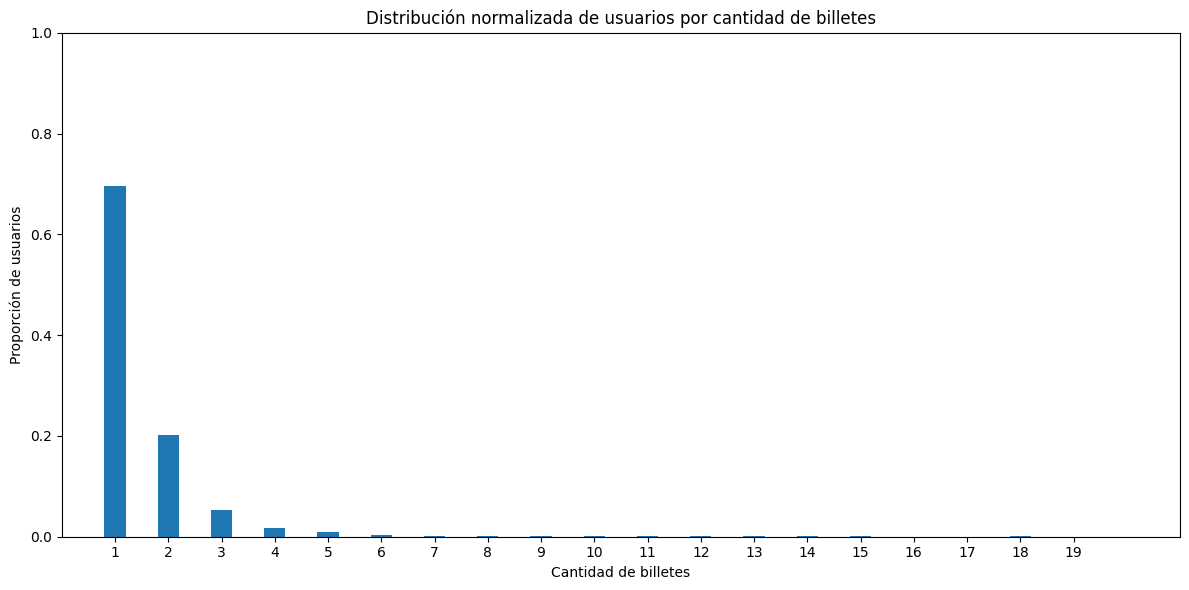

In [16]:
# Creamos el gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico para usuarios_por_billetes_df_totales
ax.bar(
    usuarios_por_billetes_normalizado.keys(),
    usuarios_por_billetes_normalizado.values(),
    width=0.4,
    align='center'
)

# Configurar etiquetas y leyenda
ax.set_xlabel('Cantidad de billetes')
ax.set_ylabel('Proporción de usuarios')
ax.set_title('Distribución normalizada de usuarios por cantidad de billetes')
plt.xticks(range(1, 20))  # Cortamos en 20 billetes porque se hace inapreciable
plt.xlim(0, 21)  # Ajustar los límites del eje x
plt.ylim(0, 1)  # Ajustar los límites del eje y
plt.tight_layout()

# Guardamos la figura
fig.savefig("../figuras/usuarios_por_num_billetes.pdf")

plt.show()

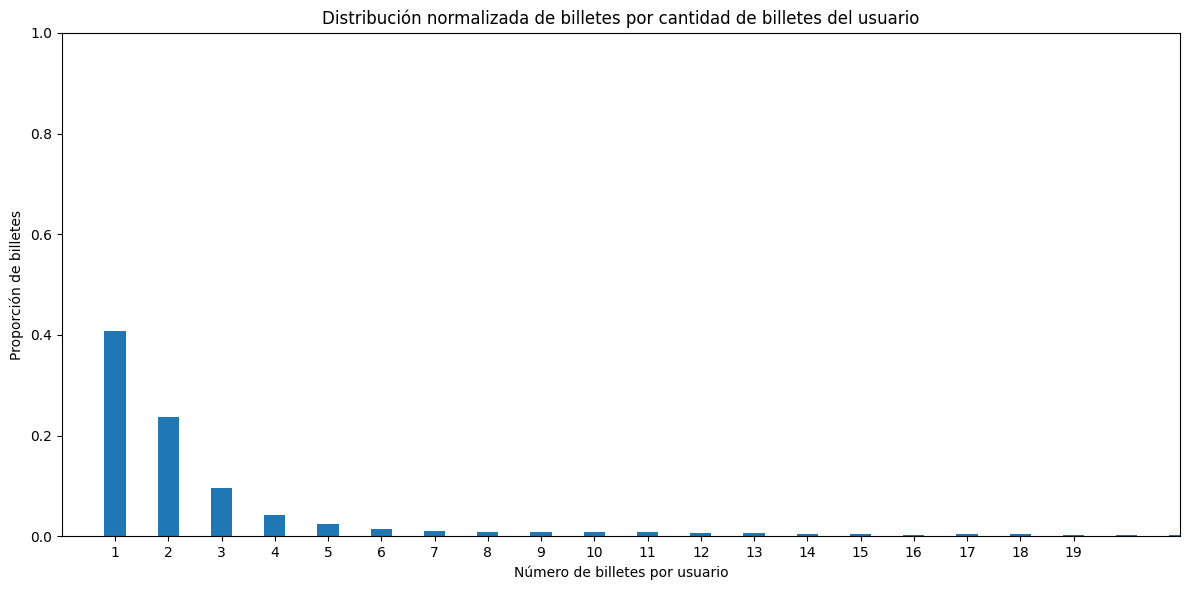

In [17]:
# Creamos el gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico para usuarios_por_billetes_df_totales
ax.bar(
    billetes_por_cantidad_de_billetes_normalizado.keys(),
    billetes_por_cantidad_de_billetes_normalizado.values(),
    width=0.4,
    align='center'
)

# Configurar etiquetas y leyenda
ax.set_xlabel('Número de billetes por usuario')
ax.set_ylabel('Proporción de billetes')
ax.set_title('Distribución normalizada de billetes por cantidad de billetes del usuario')


plt.xticks(range(1, 20))  # Cortamos en 20 billetes porque se hace inapreciable
plt.xlim(0, 21)  # Ajustar los límites del eje x
plt.ylim(0, 1)  # Ajustar los límites del eje y
plt.tight_layout()

# Guardamos la figura
fig.savefig("../figuras/billetes_por_num_billetes.pdf")

plt.show()

In [18]:
# Si eliminamos los usuarios con un único billete:
print(f"Billetes antes del filtrado: {billetes_finales}")

k = 2
vc = df_total['Usuario'].value_counts()
usuarios_validos = vc[vc >= k].index

df_rec = df_total[df_total['Usuario'].isin(usuarios_validos)].copy()

print(f"Billetes tras filtrar (k={k}): {len(df_rec)}")
print(f"Usuarios tras filtrar: {df_rec['Usuario'].nunique()}")
print(f"Media interacciones/usuario: {len(df_rec) / df_rec['Usuario'].nunique():.2f}")


Billetes antes del filtrado: 106681
Billetes tras filtrar (k=2): 62963
Usuarios tras filtrar: 18968
Media interacciones/usuario: 3.32


### Análisis de combinaciones origen-destino

Billetes usados en el heatmap (solo rutas válidas): 106438


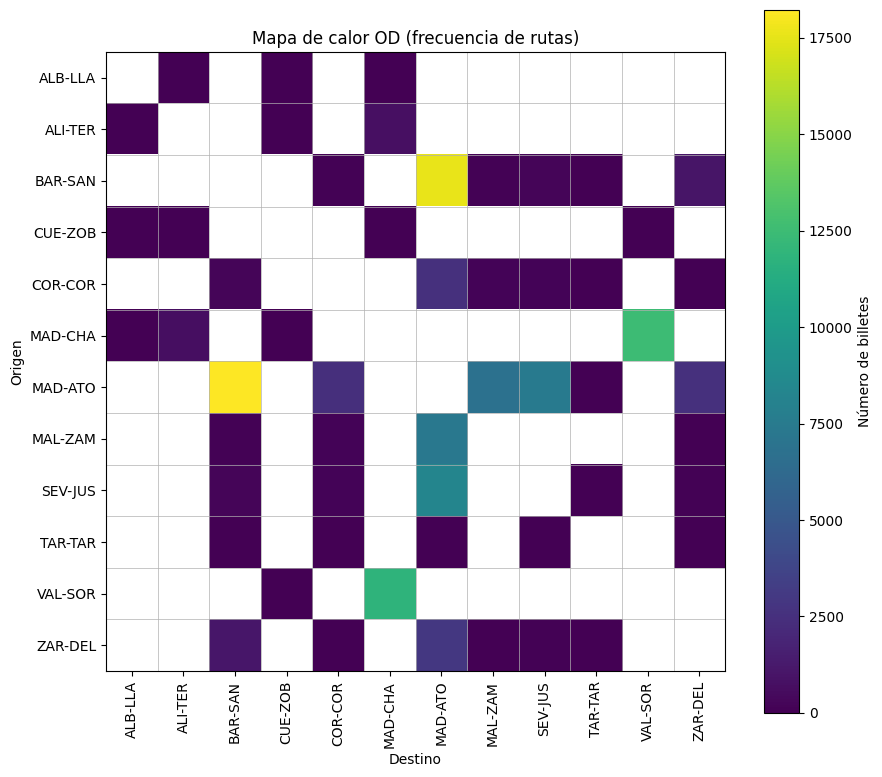

In [19]:
# Estaciones únicas SOLO de rutas válidas
estaciones = sorted({s for o, d in rutas_validas for s in (o, d)})
n = len(estaciones)

# Abreviaturas sin colisiones
abbr = {}
used = set()
for s in estaciones:
    a = make_abbr(s)
    if a in used:
        k = 2
        while f"{a}{k}" in used:
            k += 1
        a = f"{a}{k}"
    abbr[s] = a
    used.add(a)

idx = {s: i for i, s in enumerate(estaciones)}


# Conteo real en df_total, filtrando solo rutas válidas
od_tuplas = list(zip(df_total['Origen'], df_total['Destino']))
mask_validas = [od in rutas_validas for od in od_tuplas]

df_od = df_total.loc[mask_validas, ['Origen', 'Destino']].copy()

# Conteo por ruta dirigida (Origen->Destino)
conteos = df_od.groupby(['Origen', 'Destino']).size().to_dict()


# Matriz OD con NaN en rutas NO existentes (para no pintarlas)

M = np.full((n, n), np.nan)

# Solo rellenamos rutas válidas
for (o, d) in rutas_validas:
    io, id_ = idx[o], idx[d]
    M[io, id_] = conteos.get((o, d), 0)

print(f"Billetes usados en el heatmap (solo rutas válidas): {len(df_od)}")


# Plot
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(9, 8))

# Enmascaramos NaN para que no se vean (celdas que no existen)
M_masked = np.ma.masked_invalid(M)

cmap = plt.cm.viridis
cmap.set_bad(color="white")  # rutas no existentes en blanco

im = ax.imshow(M_masked, cmap=cmap)

labels = [abbr[s] for s in estaciones]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_xlabel("Destino")
ax.set_ylabel("Origen")
ax.set_title("Mapa de calor OD (frecuencia de rutas)")

ax.set_xticks(np.arange(-.5, n, 1), minor=True)
ax.set_yticks(np.arange(-.5, n, 1), minor=True)
ax.grid(which="minor", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Número de billetes")

fig.tight_layout()

# Guardamos archivo
fig.savefig("../figuras/od_heatmap_frecuencias_validas.pdf")

plt.show()

In [20]:
# Nos quedamos solo con rutas válidas (y ponemos 0 si no aparece en df_total)
conteos_od_validos = {od: conteos.get(od, 0) for od in rutas_validas}

# Ordenamos de mayor a menor para verlo fácil
conteos_od_validos_ordenado = dict(
    sorted(conteos_od_validos.items(), key=lambda x: x[1], reverse=True)
)


print("Rutas por número de billetes:")
for (o, d), c in list(conteos_od_validos_ordenado.items()):
    print(f"{o} -> {d}: {c}")


Rutas por número de billetes:
Madrid-Puerta de Atocha -> Barcelona-Sants: 18225
Barcelona-Sants -> Madrid-Puerta de Atocha: 17637
Madrid-Chamartín -> Valencia-Joaquín Sorolla: 12506
Valencia-Joaquín Sorolla -> Madrid-Chamartín: 11835
Sevilla-Santa Justa -> Madrid-Puerta de Atocha: 8317
Madrid-Puerta de Atocha -> Sevilla-Santa Justa: 7424
Málaga-María Zambrano -> Madrid-Puerta de Atocha: 7277
Madrid-Puerta de Atocha -> Málaga-María Zambrano: 6767
Zaragoza-Delicias -> Madrid-Puerta de Atocha: 2957
Córdoba -> Madrid-Puerta de Atocha: 2549
Madrid-Puerta de Atocha -> Zaragoza-Delicias: 2549
Madrid-Puerta de Atocha -> Córdoba: 2432
Zaragoza-Delicias -> Barcelona-Sants: 1120
Barcelona-Sants -> Zaragoza-Delicias: 1010
Alicante-Terminal -> Madrid-Chamartín: 777
Madrid-Chamartín -> Alicante-Terminal: 686
Barcelona-Sants -> Sevilla-Santa Justa: 282
Sevilla-Santa Justa -> Barcelona-Sants: 276
Córdoba -> Barcelona-Sants: 217
Málaga-María Zambrano -> Córdoba: 203
Sevilla-Santa Justa -> Córdoba: 195


Veamos qué porcentaje de los datos representan las rutas más repetidas

In [21]:
# Top rutas y concentración

# DataFrame con conteos ya filtrados a rutas válidas
df_conteos_od = pd.DataFrame(
    [({'Origen': o, 'Destino': d, 'Billetes': c}) for (o, d), c in conteos_od_validos_ordenado.items()]
)

# Total de billetes en rutas válidas (los que entran en este análisis)
total_billetes_rutas_validas = df_conteos_od['Billetes'].sum()

print(f"Billetes totales en rutas válidas: {total_billetes_rutas_validas}")

# Top-k rutas
for k in [5, 10, 20]:
    topk = df_conteos_od.head(k)['Billetes'].sum()
    print(f"Porcentaje de billetes en top-{k} rutas: {topk / total_billetes_rutas_validas:.2%}")

# Tabla top-10
df_top10_rutas = df_conteos_od.head(10).copy()
df_top10_rutas['Proporción'] = df_top10_rutas['Billetes'] / total_billetes_rutas_validas
df_top10_rutas


Billetes totales en rutas válidas: 106438
Porcentaje de billetes en top-5 rutas: 64.38%
Porcentaje de billetes en top-10 rutas: 89.72%
Porcentaje de billetes en top-20 rutas: 98.69%


,Origen,Destino,Billetes,Proporción
0,Madrid-Puerta de Atocha,Barcelona-Sants,18225,0.171226
1,Barcelona-Sants,Madrid-Puerta de Atocha,17637,0.165702
2,Madrid-Chamartín,Valencia-Joaquín Sorolla,12506,0.117496
3,Valencia-Joaquín Sorolla,Madrid-Chamartín,11835,0.111191
4,Sevilla-Santa Justa,Madrid-Puerta de Atocha,8317,0.078139
5,Madrid-Puerta de Atocha,Sevilla-Santa Justa,7424,0.069750
6,Málaga-María Zambrano,Madrid-Puerta de Atocha,7277,0.068368
7,Madrid-Puerta de Atocha,Málaga-María Zambrano,6767,0.063577
8,Zaragoza-Delicias,Madrid-Puerta de Atocha,2957,0.027781
9,Córdoba,Madrid-Puerta de Atocha,2549,0.023948



Productos detectados (columnas):
['Infinita', 'Infinita Bistró', 'Infinita Bistró Abierta', 'Infinita abierta', 'Inicial', 'Singular', 'Singular  Abierta', 'Singular AC', 'Singular Only You', 'Singular Only You Abierta']

Tabla % producto por ruta (top) (en %):


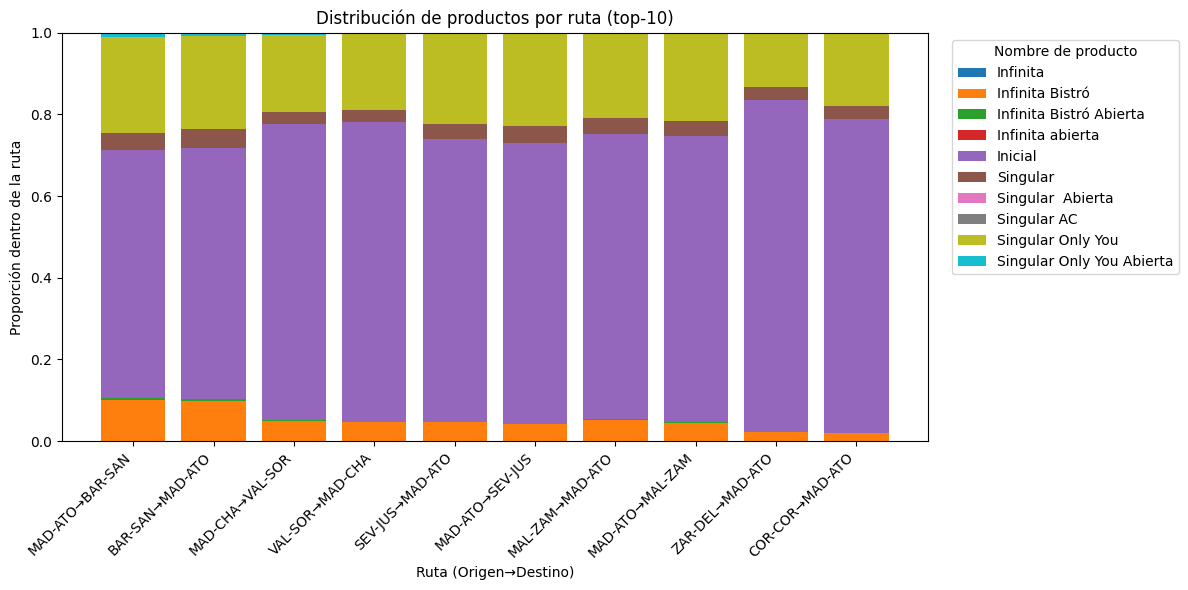


Distribución global de productos en top-10 rutas (recuento):
Nombre de producto
Inicial                      64806
Singular Only You            20165
Infinita Bistró               6258
Singular                      3563
Singular Only You Abierta      463
Infinita Bistró Abierta        188
Singular  Abierta               24
Singular AC                     24
Infinita                         2
Infinita abierta                 1

Distribución global de productos en top-10 rutas (porcentaje):
 - Inicial: 67.86%
 - Singular Only You: 21.12%
 - Infinita Bistró: 6.55%
 - Singular: 3.73%
 - Singular Only You Abierta: 0.48%
 - Infinita Bistró Abierta: 0.20%
 - Singular  Abierta: 0.03%
 - Singular AC: 0.03%
 - Infinita: 0.00%
 - Infinita abierta: 0.00%


In [22]:
# Parámetros: cuántas rutas top analizar
TOP_RUTAS = 10

# Columnas mínimas para este análisis
cols_prod = ['Origen', 'Destino', 'Nombre de producto']

# Filtramos df_total a rutas válidas y columnas necesarias
df_prod = df_total.loc[:, cols_prod].copy()

# Filtrado por rutas válidas con merge
df_rutas_validas = pd.DataFrame(list(rutas_validas), columns=['Origen', 'Destino'])
df_prod = df_prod.merge(df_rutas_validas, on=['Origen', 'Destino'], how='inner')

# Seleccionamos las TOP_RUTAS según el ranking que ya calculaste (conteos_od_validos_ordenado)
top_rutas = list(conteos_od_validos_ordenado.keys())[:TOP_RUTAS]

# DataFrame con top rutas para filtrar rápido
df_top_rutas = pd.DataFrame(top_rutas, columns=['Origen', 'Destino'])

# Filtramos solo billetes de las top rutas
df_prod_top = df_prod.merge(df_top_rutas, on=['Origen', 'Destino'], how='inner')

ct_counts = pd.crosstab(
    index=[df_prod_top['Origen'], df_prod_top['Destino']],
    columns=df_prod_top['Nombre de producto'],
    dropna=False
)

ct_norm = pd.crosstab(
    index=[df_prod_top['Origen'], df_prod_top['Destino']],
    columns=df_prod_top['Nombre de producto'],
    normalize='index',
    dropna=False
)

# Ordenamos las filas con el mismo orden del ranking (por si crosstab las reordena)
ct_counts = ct_counts.reindex(pd.MultiIndex.from_tuples(top_rutas, names=['Origen', 'Destino']))
ct_norm = ct_norm.reindex(pd.MultiIndex.from_tuples(top_rutas, names=['Origen', 'Destino']))

print("\nProductos detectados (columnas):")
print(list(ct_counts.columns))


ct_norm_pct = (ct_norm * 100).round(2)

total_por_ruta = ct_counts.sum(axis=1)

# Añadimos también el total de billetes por ruta para contexto
tabla_prod_ruta = ct_norm_pct.copy()
tabla_prod_ruta.insert(0, 'Billetes (top ruta)', total_por_ruta.astype(int).values)

# Pasamos el índice MultiIndex a columnas para que sea fácil exportar a LaTeX
tabla_prod_ruta = tabla_prod_ruta.reset_index()
tabla_prod_ruta.rename(columns={'Origen': 'Origen', 'Destino': 'Destino'}, inplace=True)

print("\nTabla % producto por ruta (top) (en %):")
tabla_prod_ruta

# Etiquetas de ruta (abreviadas si ya tienes 'abbr'; si no, usa texto completo)
def ruta_label(o, d):
    # Si existe abbr, la usamos; si no, devolvemos nombres completos
    if 'abbr' in globals() and isinstance(abbr, dict) and o in abbr and d in abbr:
        return f"{abbr[o]}→{abbr[d]}"
    return f"{o}→{d}"

labels_rutas = [ruta_label(o, d) for (o, d) in top_rutas]

# Matriz de proporciones para plot (en orden de top_rutas)
X = (ct_norm.reindex(pd.MultiIndex.from_tuples(top_rutas))).fillna(0.0)
productos = list(X.columns)

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(X))
x = np.arange(len(X))

for prod in productos:
    vals = X[prod].values
    ax.bar(x, vals, bottom=bottom, label=str(prod))
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(labels_rutas, rotation=45, ha='right')
ax.set_ylim(0, 1)

ax.set_xlabel("Ruta (Origen→Destino)")
ax.set_ylabel("Proporción dentro de la ruta")
ax.set_title(f"Distribución de productos por ruta (top-{TOP_RUTAS})")

ax.legend(title="Nombre de producto", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

fig.savefig(f"../figuras/productos_por_ruta_top{TOP_RUTAS}_stacked.pdf")
plt.show()

# Resumen global de productos de dentro de las top rutas
dist_prod_top = df_prod_top['Nombre de producto'].value_counts()
dist_prod_top_pct = (dist_prod_top / dist_prod_top.sum() * 100).round(2)

print(f"\nDistribución global de productos en top-{TOP_RUTAS} rutas (recuento):")
print(dist_prod_top.to_string())

print(f"\nDistribución global de productos en top-{TOP_RUTAS} rutas (porcentaje):")
for prod, p in dist_prod_top_pct.items():
    print(f" - {prod}: {p:.2f}%")

Ahora seguimos con el análisis de la variable tipo de producto


Número de productos distintos: 10

Distribución de productos (recuento):
Nombre de producto
Inicial                      72938
Singular Only You            22123
Infinita Bistró               6633
Singular                      3992
Singular Only You Abierta      489
Infinita Bistró Abierta        202
Singular AC                     32
Singular  Abierta               24
Infinita                         4
Infinita abierta                 1

Distribución de productos (porcentaje):
 - Inicial: 68.53%
 - Singular Only You: 20.78%
 - Infinita Bistró: 6.23%
 - Singular: 3.75%
 - Singular Only You Abierta: 0.46%
 - Infinita Bistró Abierta: 0.19%
 - Singular AC: 0.03%
 - Singular  Abierta: 0.02%
 - Infinita: 0.00%
 - Infinita abierta: 0.00%


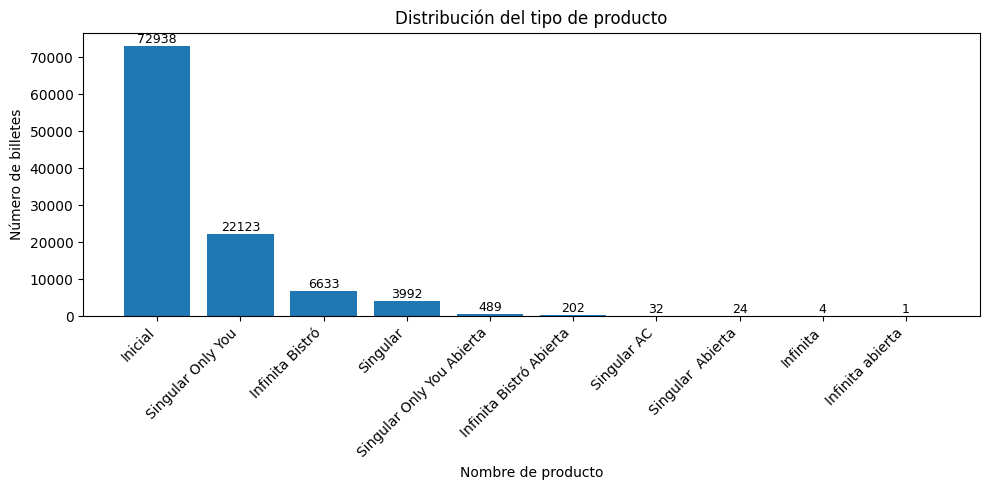

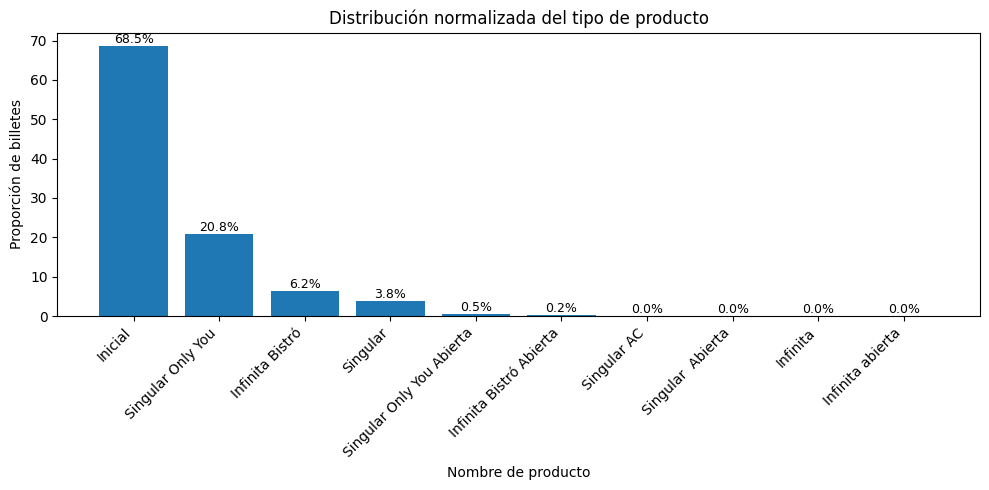

In [23]:
# Distribución global de "Nombre de producto" en df_total
col_prod = 'Nombre de producto'

# Conteo
n_total = len(df_total)

# Quitamos NaN para analizar distribución de productos
s_prod = df_total[col_prod].dropna()

# Conteos y porcentajes
prod_counts = s_prod.value_counts()
prod_pct = (prod_counts / prod_counts.sum()) * 100

print(f"\nNúmero de productos distintos: {prod_counts.shape[0]}")
print("\nDistribución de productos (recuento):")
print(prod_counts.to_string())

print("\nDistribución de productos (porcentaje):")
for p, v in prod_pct.round(2).items():
    print(f" - {p}: {v:.2f}%")

# Baseline: recomendar siempre el producto más frecuente
prod_moda = prod_counts.index[0]
prod_moda_pct = prod_pct.iloc[0]

# Tabla de distribución
df_dist_producto = pd.DataFrame({
    'Producto': prod_counts.index,
    'Billetes': prod_counts.values,
    'Porcentaje': (prod_pct.values / 100)  # en proporción (0-1) por si luego haces LaTeX
})
df_dist_producto

# %%
# Figura: distribución de productos (barras, recuento)
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(prod_counts))
ax.bar(x, prod_counts.values)

ax.set_xticks(x)
ax.set_xticklabels(prod_counts.index, rotation=45, ha='right')
ax.set_xlabel("Nombre de producto")
ax.set_ylabel("Número de billetes")
ax.set_title("Distribución del tipo de producto")

# Anotaciones
for i, v in enumerate(prod_counts.values):
    ax.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig("../figuras/distribucion_producto_recuento.pdf")
plt.show()

# Figura: distribución de productos (barras, porcentaje)
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x, prod_pct.values)

ax.set_xticks(x)
ax.set_xticklabels(prod_counts.index, rotation=45, ha='right')
ax.set_xlabel("Nombre de producto")
ax.set_ylabel("Proporción de billetes")
ax.set_title("Distribución normalizada del tipo de producto")

for i, v in enumerate(prod_pct.values):
    ax.text(i, v, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig("../figuras/distribucion_producto_porcentaje.pdf")
plt.show()

Usuarios totales (df_total): 62443
Media billetes/usuario (df_total): 1.70

Usuarios por k (top 10):
1     43475
2     12638
3      3367
4      1105
5       525
6       246
7       145
8       124
9       106
10       88

--- k == 1 ---
Billetes en el grupo: 43475
NaN en producto: 0 (0.00%)
Productos distintos (sin NaN): 8

Distribución (recuento):
Nombre de producto
Inicial                      30479
Singular Only You             8458
Infinita Bistró               2378
Singular                      1936
Singular Only You Abierta      124
Infinita Bistró Abierta         69
Singular AC                     22
Singular  Abierta                9

Distribución (porcentaje):
 - Inicial: 70.11%
 - Singular Only You: 19.45%
 - Infinita Bistró: 5.47%
 - Singular: 4.45%
 - Singular Only You Abierta: 0.29%
 - Infinita Bistró Abierta: 0.16%
 - Singular AC: 0.05%
 - Singular  Abierta: 0.02%

--- k == 2 ---
Billetes en el grupo: 25276
NaN en producto: 0 (0.00%)
Productos distintos (sin NaN): 8

Dist

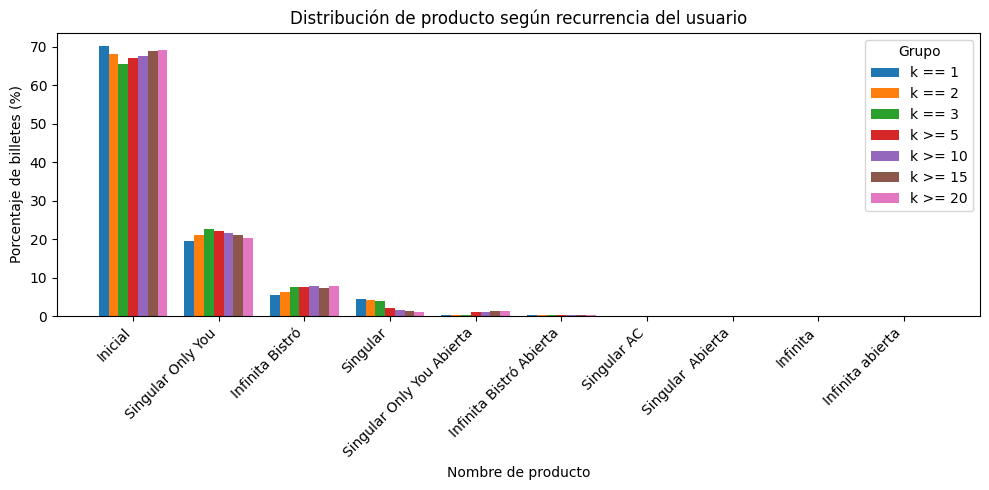

In [24]:
# ### Distribución de tipo de producto según recurrencia (k billetes por usuario)

col_user = 'Usuario'
col_prod = 'Nombre de producto'

# Contamos billetes por usuario en df_total (vectorizado)
k_por_usuario = df_total.groupby(col_user).size()

print(f"Usuarios totales (df_total): {k_por_usuario.shape[0]}")
print(f"Media billetes/usuario (df_total): {k_por_usuario.mean():.2f}")
print("\nUsuarios por k (top 10):")
print(k_por_usuario.value_counts().head(10).to_string())

def distribucion_producto_por_grupo(df, mask, nombre_grupo):
    """
    Calcula distribución de producto (recuento y %) para el subconjunto df[mask],
    ignorando NaN en producto, e imprime baseline.
    """
    sub = df.loc[mask, [col_prod]].copy()
    n_total = len(sub)
    n_nan = sub[col_prod].isna().sum()

    sub = sub.dropna(subset=[col_prod])
    counts = sub[col_prod].value_counts()
    pct = (counts / counts.sum()) * 100

    print(f"\n--- {nombre_grupo} ---")
    print(f"Billetes en el grupo: {n_total}")
    print(f"NaN en producto: {n_nan} ({n_nan/n_total:.2%})")
    print(f"Productos distintos (sin NaN): {counts.shape[0]}")
    print("\nDistribución (recuento):")
    print(counts.to_string())
    print("\nDistribución (porcentaje):")
    for p, v in pct.round(2).items():
        print(f" - {p}: {v:.2f}%")

    out = pd.DataFrame({'Billetes': counts.values, 'Porcentaje': (pct.values / 100)}, index=counts.index)
    out.index.name = 'Producto'
    return out

# Definimos grupos por recurrencia del usuario (k billetes)
# Nota: "k exacto" y "k >= umbral"
grupos = [
    ("k == 1",  (k_por_usuario == 1)),
    ("k == 2",  (k_por_usuario == 2)),
    ("k == 3",  (k_por_usuario == 3)),
    ("k >= 5",  (k_por_usuario >= 5)),
    ("k >= 10",  (k_por_usuario >= 10)),
    ("k >= 15",  (k_por_usuario >= 15)),
    ("k >= 20",  (k_por_usuario >= 20)),
]

# Creamos una columna auxiliar con k por billete (mapeo vectorizado)
# (evita merges y es rápido)
df_aux = df_total[[col_user, col_prod]].copy()
df_aux['k_usuario'] = df_aux[col_user].map(k_por_usuario)

# Calculamos y guardamos distribuciones por grupo
dist_por_grupo = {}

for nombre, cond_usuarios in grupos:
    # Máscara a nivel billete: billetes cuyo usuario cumple la condición
    mask_billetes = df_aux[col_user].isin(k_por_usuario.index[cond_usuarios])
    dist_por_grupo[nombre] = distribucion_producto_por_grupo(df_aux, mask_billetes, nombre)

# Tabla comparativa (porcentaje)
df_comp = pd.concat(
    {g: dist_por_grupo[g]['Porcentaje'] for g, _ in grupos},
    axis=1
).fillna(0.0)

# Ordenamos productos por frecuencia global (df_total sin NaN)
orden_productos = df_total[col_prod].dropna().value_counts().index
df_comp = df_comp.reindex(orden_productos)

print("\nTabla comparativa (% en proporción 0-1) por grupo:")
df_comp

# Figura:
grupos_plot = ["k == 1", "k == 2", "k == 3", "k >= 5", "k >= 10", "k >= 15", "k >= 20"]

df_plot = (df_comp[grupos_plot] * 100)  # a %
x = np.arange(df_plot.shape[0])

fig, ax = plt.subplots(figsize=(10, 5))

# Barras agrupadas
width = 0.8 / len(grupos_plot)
for i, g in enumerate(grupos_plot):
    ax.bar(x + (i - (len(grupos_plot)-1)/2) * width, df_plot[g].values, width=width, label=g)

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=45, ha='right')
ax.set_xlabel("Nombre de producto")
ax.set_ylabel("Porcentaje de billetes (%)")
ax.set_title("Distribución de producto según recurrencia del usuario")

ax.legend(title="Grupo")
fig.tight_layout()
fig.savefig("../figuras/distribucion_producto_por_k_usuario_comparativa.pdf")
plt.show()

Finalizamos esta sección, exportando los datos para cargarlos en el siguiente cuaderno

In [25]:
# Arreglar tipos para poder exportar a parquet
df_total['Localizador'] = df_total['Localizador'].astype('string').str.strip().str.upper()

# Exportamos los datos procesados
df_total.to_parquet("../data/billetes_procesados.parquet", index=False)


También los guardamos en excel para revisarlos manualmente y asegurarnos de que no hay ningún error

In [26]:
df_total.to_excel("../data/billetes_procesados_para_revision.xlsx", index=False)